In [2]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
df = pd.read_csv("~/Documents/Paris/Internship/Analyses/Pilot-Data/Big-Sets/Clean/transnote_data_Clean_ALL_IMPROV_pilots.csv", 
                  index_col = 0)

### Create functions

In [4]:
# Define a permutation sampling function.

def permutation_sample(data1, data2):
    """Generate a permutation sample from two data sets."""

    # Concatenate the data sets: add the data together whilst ignore the label. 
    data = np.concatenate((data1, data2))

    # Permute the concatenated array: permuted_data. Random reordering.
    permuted_data = np.random.permutation(data)

    # Split the permuted array into two: perm_sample_1, perm_sample_2. Re-label the permuted data.
    perm_sample_1 = permuted_data[:len(data1)]
    perm_sample_2 = permuted_data[len(data1):]

    return perm_sample_1, perm_sample_2

In [5]:
# Perform a permuation test: obtain permutation replicates for both groups.

def draw_perm_reps(data_1, data_2, func, size=1):
    """Generate multiple permutation replicates."""

    # Initialize array of replicates: perm_replicates
    perm_replicates = np.empty(size)

    for i in range(size):
        # Generate permutation sample
        perm_sample_1, perm_sample_2 = permutation_sample(data_1, data_2)

        # Compute the test statistic
        perm_replicates[i] = func(perm_sample_1, perm_sample_2)
    return perm_replicates

In [6]:
# Estimate the p-value: probability of obtaining a value of the test statistic as extreme as the observed one, under the
# assumption that the null hypothesis is true.

def diff_of_means(data_1, data_2):
    """Difference in means of two arrays."""

    # The difference of means of data_1, data_2: diff
    diff = np.mean(data_1)-np.mean(data_2) #Not symmetric matrices.

    return diff

### Null Hypothesis

In [7]:
# Formulate a null hypothesis.
# H0: the probability distribution of the person is identical to a random distribution.
# H0: identical probability distribution for people of different cohorts & same cohorts.
# H0: identical probability distribution for trained musicians and non-trained musicians.

musician_1 = df[df['PARTICIPANT_ID']==888]
musician_2 = df[df['PARTICIPANT_ID']==999]
non_musician = df[df['PARTICIPANT_ID']==111]

In [12]:
trial_1 = np.zeros((12,12))

for song in musician_1['SONG_ID']: # for 888
    extract = musician_1[musician_1['SONG_ID']== song]
    ex_unlabeled = extract.drop(['PARTICIPANT_ID', 'SONG_ID'], axis=1)
    ex_arr = ex_unlabeled.to_numpy()
    trial_1 = np.add(trial_1, ex_arr)
    
trial_2 = np.zeros((12,12))

for song in musician_2['SONG_ID']: # for 999
    extract = musician_2[musician_2['SONG_ID']== song]
    ex_unlabeled = extract.drop(['PARTICIPANT_ID', 'SONG_ID'], axis=1)
    ex_arr = ex_unlabeled.to_numpy()
    trial_2 = np.add(trial_2, ex_arr)

trial_3 = np.zeros((12,12))

for song in non_musician['SONG_ID']: # for 111
    extract = non_musician[non_musician['SONG_ID']== song]
    ex_unlabeled = extract.drop(['PARTICIPANT_ID', 'SONG_ID'], axis=1)
#     ex_total_sum =  ex_unlabeled.sum()
#     ex_normalized = ex_unlabeled/ex_total_sum # Divide the extracted matrix by the total amount of notes reported (normalize)
#     ex_arr = ex_normalized.to_numpy()
    ex_arr = ex_unlabeled.to_numpy()
    trial_3 = zip(trial_3, ex_arr)

In [65]:
# a = np.ones((12,12))
# b = np.ones((12,12))

# al = list(a[0])
# bl = list(b[0])

# at = tuple()
# aa = tuple()
# for el in al:
#     at = at + tuple(str(int(el)))

# # XX = zip(al, bl)
# print(at)

('1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1')


#### Permuted datasets

In [8]:
# Create permuted samples for musicians
perm_arr_1 = np.zeros((12,12))
perm_arr_2 = np.zeros((12,12))

for _ in range(30):
    # Generate permutation samples
    # perm_sample_1, perm_sample_2 = permutation_sample(musician_unlabeled, non_musician_unlabeled)
    perm_sample_1, perm_sample_2 = permutation_sample(trial_1, trial_2)
    
    # Add the permuted arrays
    perm_arr_1 = np.add(perm_arr_1, perm_sample_1)
    perm_arr_2 = np.add(perm_arr_2, perm_sample_2)

# Compare musician_1 with non-musician
perm_arr_3 = np.zeros((12,12))
perm_arr_4 = np.zeros((12,12))

for _ in range(1000):
    perm_sample_3, perm_sample_4 = permutation_sample(trial_1, trial_3)
    
    # Add the permuted arrays
    perm_arr_3 = np.add(perm_arr_3, perm_sample_3)
    perm_arr_4 = np.add(perm_arr_4, perm_sample_4)

# Compare musician_2 with non-musician
perm_arr_5 = np.zeros((12,12))
perm_arr_6 = np.zeros((12,12))

for _ in range(1000):
    perm_sample_5, perm_sample_6 = permutation_sample(trial_2, trial_3)
    
    # Add the permuted arrays
    perm_arr_5 = np.add(perm_arr_5, perm_sample_5)
    perm_arr_6 = np.add(perm_arr_6, perm_sample_6)

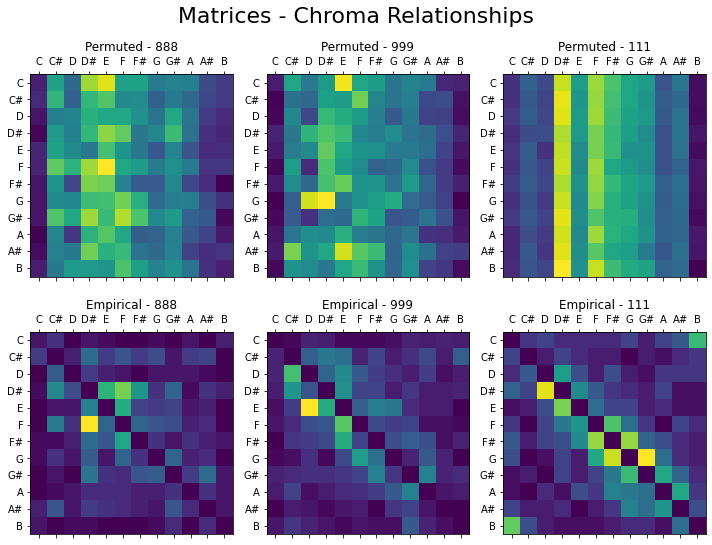

In [10]:
# Plot permuted agains empirical matrices

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6))  = plt.subplots(nrows=2, ncols=3, tight_layout=True)

# Plot permutation samples
ax1.matshow(perm_arr_1)
ax2.matshow(perm_arr_2)
ax3.matshow(perm_arr_4)
ax1.set_title('Permuted - 888')
ax1.set_xticks(list(range(0, 12)))
ax1.set_xticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
ax1.set_yticks(list(range(0, 12)))
ax1.set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])

ax2.set_title('Permuted - 999')
ax2.set_xticks(list(range(0, 12)))
ax2.set_xticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
ax2.set_yticks(list(range(0, 12)))
ax2.set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])

ax3.set_title('Permuted - 111')
ax3.set_xticks(list(range(0, 12)))
ax3.set_xticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
ax3.set_yticks(list(range(0, 12)))
ax3.set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])

# Plot original data
ax4.matshow(trial_1)
ax4.set_xticks(list(range(0, 12)))
ax4.set_xticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
ax4.set_yticks(list(range(0, 12)))
ax4.set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])

ax5.matshow(trial_2)
ax5.set_xticks(list(range(0, 12)))
ax5.set_xticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
ax5.set_yticks(list(range(0, 12)))
ax5.set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])

ax6.matshow(trial_3)
ax6.set_xticks(list(range(0, 12)))
ax6.set_xticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])
ax6.set_yticks(list(range(0, 12)))
ax6.set_yticklabels(["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])

ax4.set_title('Empirical - 888')
ax5.set_title('Empirical - 999')
ax6.set_title('Empirical - 111')

fig.suptitle('Matrices - Chroma Relationships', fontsize=22, ha='center')
fig.set_figheight(8)
fig.set_figwidth(10)

fig.savefig('Chroma_Permutation_IMPROV_Pilot.png', dpi=800)

#### Mean Differences

In [11]:
# Compute difference of mean impact force from experiment: empirical_diff_means
empirical_diff_means_12 = diff_of_means(trial_1, trial_2)
empirical_diff_means_13 = diff_of_means(trial_1, trial_3)
empirical_diff_means_23 = diff_of_means(trial_2, trial_3)

# Draw 1000 permutation replicates: perm_replicates
perm_replicates_12 = draw_perm_reps(trial_1, trial_2, func=diff_of_means, size=1000)
perm_replicates_13 = draw_perm_reps(trial_1, trial_3, func=diff_of_means, size=1000)
perm_replicates_23 = draw_perm_reps(trial_2, trial_3, func=diff_of_means, size=1000)

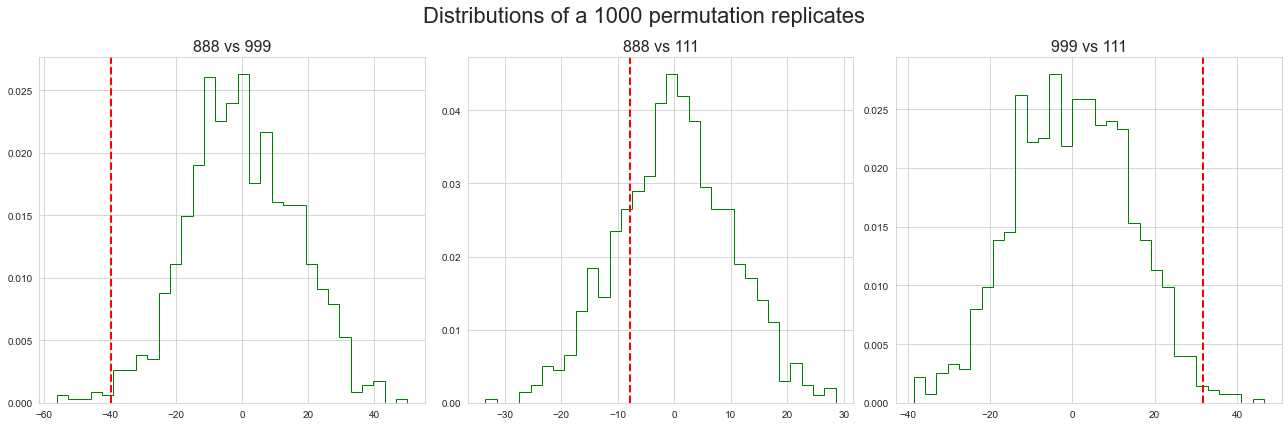

In [13]:
# Plot permuted differences of means
sns.set_style('whitegrid')
fig, ((ax1, ax2, ax3))  = plt.subplots(nrows=1, ncols=3, tight_layout=True)

# Plot permutation replicates
ax1.hist(perm_replicates_12, bins = int(math.sqrt(1000)), density=True, histtype = 'step', color='g')
ax1.axvline(empirical_diff_means_12, color='r', linestyle='dashed', linewidth=2)
ax2.hist(perm_replicates_13, bins = int(math.sqrt(1000)), density=True, histtype = 'step', color='g')
ax2.axvline(empirical_diff_means_13, color='r', linestyle='dashed', linewidth=2)
ax3.hist(perm_replicates_23, bins = int(math.sqrt(1000)), density=True, histtype = 'step', color='g')
ax3.axvline(empirical_diff_means_23, color='r', linestyle='dashed', linewidth=2)

ax1.set_title('888 vs 999', fontsize=16)
ax2.set_title('888 vs 111', fontsize=16)
ax3.set_title('999 vs 111', fontsize=16)

fig.suptitle('Distributions of a 1000 permutation replicates', fontsize=22, va='top')
fig.set_figheight(6)
fig.set_figwidth(18)

fig.savefig('Hist_Permutation_IMPROV_Pilot.png', dpi=800)

In [14]:
# Compute p-value: p
p12 = np.sum(perm_replicates_12 <=  empirical_diff_means_12) / len(perm_replicates_12)
p13 = np.sum(perm_replicates_13 <=  empirical_diff_means_13) / len(perm_replicates_13)
p23 = np.sum(perm_replicates_23 >=  empirical_diff_means_23) / len(perm_replicates_23)

# Print the result
print('p-value =', p12)

print(f"The p-value tells you that there is about {round(p12*100)} % chance that you would get the difference of means observed\n"\
        "in the experiment if distributions were exactly the same.")
#
print('p-value =', p13)

print(f"The p-value tells you that there is about {round(p13*100)} % chance that you would get the difference of means observed\n"\
        "in the experiment if distributions were exactly the same.")
#
print('p-value =', p23)

print(f"The p-value tells you that there is about {round(p23*100)} % chance that you would get the difference of means observed\n"\
        "in the experiment if distributions were exactly the same.")

p-value = 0.009
The p-value tells you that there is about 1 % chance that you would get the difference of means observed
in the experiment if distributions were exactly the same.
p-value = 0.227
The p-value tells you that there is about 23 % chance that you would get the difference of means observed
in the experiment if distributions were exactly the same.
p-value = 0.009
The p-value tells you that there is about 1 % chance that you would get the difference of means observed
in the experiment if distributions were exactly the same.
